In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from my_krml_26044382.data.weather import fetch_hourly_weather, aggregate_daily
from my_krml_26044382.features.targets import (
    compute_cci, compute_whi, whi_to_category, cci_to_label, WHC_LABELS
)

#### Download the data

In [4]:
import os
import time
import requests

yearly_dir = '../../data/raw/yearly'
os.makedirs(yearly_dir, exist_ok=True)

def download_year(year, max_retries=5):
    """Download one year of hourly data, retrying on network errors, and cache it to disk"""
    path = f'{yearly_dir}/sydney_hourly_{year}.csv'
    if os.path.exists(path):
        print(f'{year}: already downloaded, loading from disk')
        return pd.read_csv(path, parse_dates=['time'])

    for attempt in range(1, max_retries + 1):
        try:
            df_year = fetch_hourly_weather(start_date=f'{year}-01-01', end_date=f'{year}-12-31')
            df_year.to_csv(path, index=False)
            print(f'{year}: downloaded ({len(df_year)} rows)')
            time.sleep(2)
            return df_year
        except requests.exceptions.RequestException as e:
            wait = 10 * attempt
            print(f'{year}: attempt {attempt} failed ({type(e).__name__}), retrying in {wait}s')
            time.sleep(wait)

    raise RuntimeError(f'Could not download {year} after {max_retries} attempts')

df_hourly = pd.concat([download_year(year) for year in range(2000, 2026)], ignore_index=True)
df_hourly.shape

2000: already downloaded, loading from disk
2001: already downloaded, loading from disk
2002: already downloaded, loading from disk
2003: already downloaded, loading from disk
2004: already downloaded, loading from disk
2005: already downloaded, loading from disk
2006: already downloaded, loading from disk
2007: already downloaded, loading from disk
2008: already downloaded, loading from disk
2009: already downloaded, loading from disk
2010: already downloaded, loading from disk
2011: already downloaded, loading from disk
2012: already downloaded, loading from disk
2013: already downloaded, loading from disk
2014: already downloaded, loading from disk
2015: already downloaded, loading from disk
2016: already downloaded, loading from disk
2017: already downloaded, loading from disk
2018: already downloaded, loading from disk
2019: already downloaded, loading from disk
2020: already downloaded, loading from disk
2021: already downloaded, loading from disk
2022: already downloaded, loadin

(227928, 13)

In [5]:
df_hourly.to_csv('../../data/raw/sydney_hourly_2000_2025.csv', index=False)

#### Explore the hourly data

In [6]:
df_hourly.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,cloud_cover,precipitation,snowfall,dew_point_2m,apparent_temperature,rain,pressure_msl,shortwave_radiation
0,2000-01-01 00:00:00,16.2,66,15.5,30.6,91,0.0,0.0,9.8,13.9,0.0,1011.7,0.0
1,2000-01-01 01:00:00,15.9,69,15.1,30.2,97,0.0,0.0,10.1,13.7,0.0,1011.5,0.0
2,2000-01-01 02:00:00,15.6,70,15.0,29.9,98,0.0,0.0,10.2,13.5,0.0,1011.4,0.0
3,2000-01-01 03:00:00,15.5,71,15.0,29.2,98,0.0,0.0,10.2,13.4,0.0,1011.4,0.0
4,2000-01-01 04:00:00,15.5,71,15.5,29.5,99,0.0,0.0,10.2,13.3,0.0,1011.6,0.0


In [7]:
df_hourly.shape


(227928, 13)

In [8]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227928 entries, 0 to 227927
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   time                  227928 non-null  datetime64[ns]
 1   temperature_2m        227928 non-null  float64       
 2   relative_humidity_2m  227928 non-null  int64         
 3   wind_speed_10m        227928 non-null  float64       
 4   wind_gusts_10m        227928 non-null  float64       
 5   cloud_cover           227928 non-null  int64         
 6   precipitation         227928 non-null  float64       
 7   snowfall              227928 non-null  float64       
 8   dew_point_2m          227928 non-null  float64       
 9   apparent_temperature  227928 non-null  float64       
 10  rain                  227928 non-null  float64       
 11  pressure_msl          227928 non-null  float64       
 12  shortwave_radiation   227928 non-null  float64       
dtyp

In [9]:
df_hourly.describe()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,cloud_cover,precipitation,snowfall,dew_point_2m,apparent_temperature,rain,pressure_msl,shortwave_radiation
count,227928,227928.000000,227928.000000,227928.00000,227928.000000,227928.000000,227928.000000,227928.0,227928.000000,227928.000000,227928.000000,227928.000000,227928.000000
mean,2012-12-31 11:30:00,17.475345,71.705385,11.39103,25.080512,47.379286,0.089972,0.0,11.883269,16.794089,0.089972,1017.128174,195.255971
min,2000-01-01 00:00:00,1.100000,9.000000,0.00000,1.400000,0.000000,0.000000,0.0,-7.400000,-2.800000,0.000000,986.700000,0.000000
25%,2006-07-02 05:45:00,13.900000,61.000000,6.70000,15.100000,4.000000,0.000000,0.0,8.000000,12.000000,0.000000,1012.400000,0.000000
50%,2012-12-31 11:30:00,17.600000,73.000000,10.20000,23.000000,43.000000,0.000000,0.0,12.200000,16.800000,0.000000,1017.300000,7.000000
75%,2019-07-02 17:15:00,20.900000,84.000000,15.00000,33.100000,93.000000,0.000000,0.0,16.000000,21.400000,0.000000,1022.000000,362.000000
max,2025-12-31 23:00:00,42.000000,100.000000,48.80000,102.200000,100.000000,19.700000,0.0,27.400000,45.400000,19.700000,1039.500000,1125.000000
std,NaN,4.896378,15.888007,6.10796,12.621222,39.753589,0.424796,0.0,5.149921,6.347735,0.424796,7.002735,273.300068


In [10]:
df_hourly.isna().sum()

time                    0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
wind_gusts_10m          0
cloud_cover             0
precipitation           0
snowfall                0
dew_point_2m            0
apparent_temperature    0
rain                    0
pressure_msl            0
shortwave_radiation     0
dtype: int64

In [11]:
print(df_hourly['time'].min(), df_hourly['time'].max())
assert df_hourly['time'].max() < pd.Timestamp('2026-01-01')

2000-01-01 00:00:00 2025-12-31 23:00:00


In [12]:
df_daily = aggregate_daily(df_hourly)

In [13]:
print(df_daily.shape)
df_daily.head()

(9497, 20)


,date,temperature_2m,relative_humidity_2m,wind_speed_10m,cloud_cover,precipitation,wind_gusts_10m,snowfall,temperature_2m_max,temperature_2m_min,relative_humidity_2m_max,wind_speed_10m_max,cloud_cover_max,precipitation_hours,dew_point_2m,apparent_temperature,rain,pressure_msl,pressure_msl_min,shortwave_radiation
0,2000-01-01,17.391667,65.875000,16.004167,97.500000,0.0,46.8,0.0,20.1,15.4,85,20.3,100,0,10.820833,15.408333,0.0,1013.562500,1011.4,5245.0
1,2000-01-02,17.500000,83.875000,10.037500,77.208333,2.8,34.6,0.0,19.4,15.6,92,15.5,98,16,14.691667,17.650000,2.8,1017.966667,1015.8,4580.0
2,2000-01-03,19.775000,75.625000,9.350000,36.833333,0.1,44.6,0.0,23.9,14.9,94,18.7,95,1,15.095833,20.550000,0.1,1016.575000,1013.3,7633.0
3,2000-01-04,22.887500,66.041667,12.375000,51.375000,2.2,55.1,0.0,28.0,18.4,88,21.3,100,2,15.779167,23.441667,2.2,1008.929167,1005.2,6739.0
4,2000-01-05,19.179167,51.666667,12.400000,34.250000,0.0,47.2,0.0,22.8,16.2,63,15.6,97,0,8.875000,17.583333,0.0,1010.725000,1008.6,7754.0


In [14]:
full_range = pd.date_range(df_daily['date'].min(), df_daily['date'].max(), freq='D')
print(f"Expected days: {len(full_range)} | Actual days: {len(df_daily)}")
print(f"Missing days: {len(full_range.difference(df_daily['date']))}")

Expected days: 9497 | Actual days: 9497
Missing days: 0


In [15]:
df_daily['snowfall'].describe()

count    9497.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: snowfall, dtype: float64

In [16]:
df_daily['cci'] = compute_cci(df_daily)

In [17]:
df_daily['whi'] = compute_whi(df_daily)

In [18]:
df_daily['whc'] = whi_to_category(df_daily['whi'])

In [19]:
df_daily[['cci', 'whi', 'whc']].describe()

,cci,whi,whc
count,9497.000000,9497.000000,9497.0
mean,72.603870,25.307783,0.479204
std,10.154340,10.292849,0.560582
min,28.634375,6.381667,0.0
25%,67.090104,18.133333,0.0
50%,73.615104,23.840000,0.0
75%,79.393229,30.368333,1.0
max,98.889583,83.098333,3.0


In [20]:
df_daily['cci'].apply(cci_to_label).value_counts()

cci
Comfortable conditions          6271
Excellent outdoor conditions    2191
Moderate comfort                 983
Poor comfort                      52
Name: count, dtype: int64

In [21]:
df_daily['cci'].apply(cci_to_label).value_counts()

cci
Comfortable conditions          6271
Excellent outdoor conditions    2191
Moderate comfort                 983
Poor comfort                      52
Name: count, dtype: int64

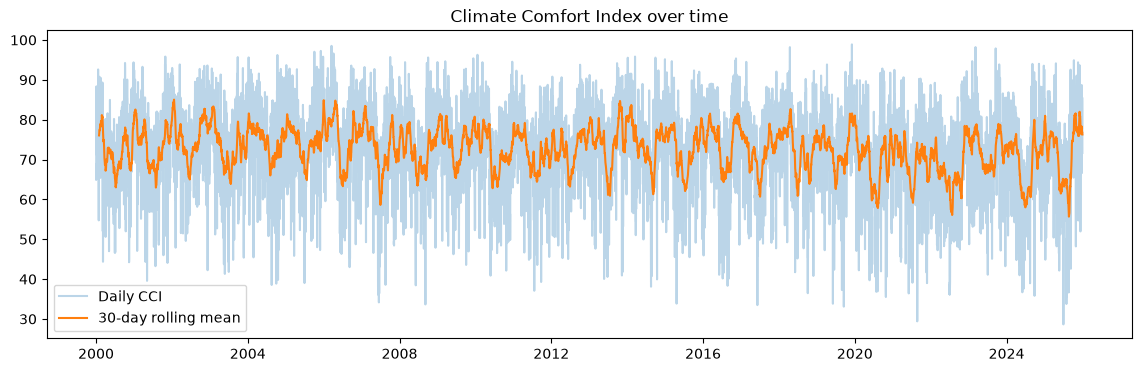

In [22]:
cci_series = df_daily.set_index('date')['cci']

plt.figure(figsize=(14, 4))
plt.plot(cci_series, alpha=0.3, label='Daily CCI')
plt.plot(cci_series.rolling(30).mean(), label='30-day rolling mean')
plt.title('Climate Comfort Index over time')
plt.legend()
plt.show()

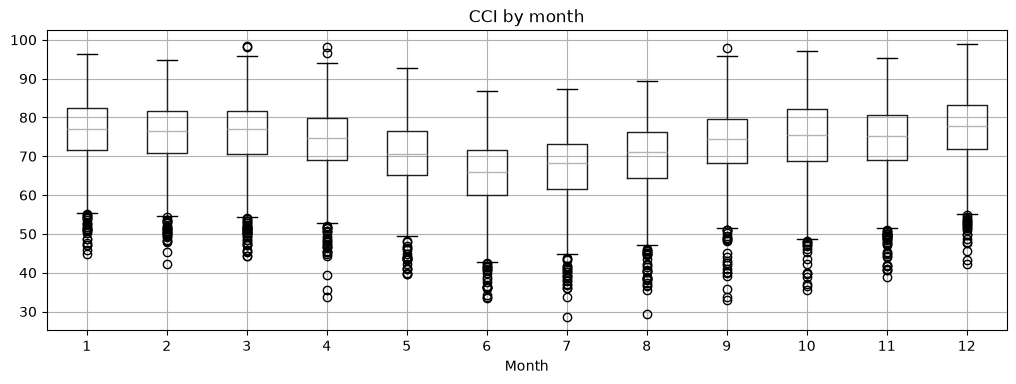

In [23]:
df_plot = df_daily.assign(month=df_daily['date'].dt.month)

df_plot.boxplot(column='cci', by='month', figsize=(12, 4))
plt.title('CCI by month')
plt.suptitle('')
plt.xlabel('Month')
plt.show()

In [24]:
for lag in [1, 2, 3, 7, 365]:
    print(f"Autocorrelation lag {lag}: {df_daily['cci'].autocorr(lag=lag):.3f}")

Autocorrelation lag 1: 0.605
Autocorrelation lag 2: 0.376
Autocorrelation lag 3: 0.289
Autocorrelation lag 7: 0.201
Autocorrelation lag 365: 0.149


In [25]:
whc_counts = pd.DataFrame({
    'label': [WHC_LABELS[c] for c in range(4)],
    'count': [(df_daily['whc'] == c).sum() for c in range(4)],
})
whc_counts['percent'] = (whc_counts['count'] / whc_counts['count'].sum() * 100).round(2)
whc_counts

,label,count,percent
0,Low Risk,5242,55.20
1,Moderate Risk,3970,41.80
2,High Risk,274,2.89
3,Extreme Risk,11,0.12


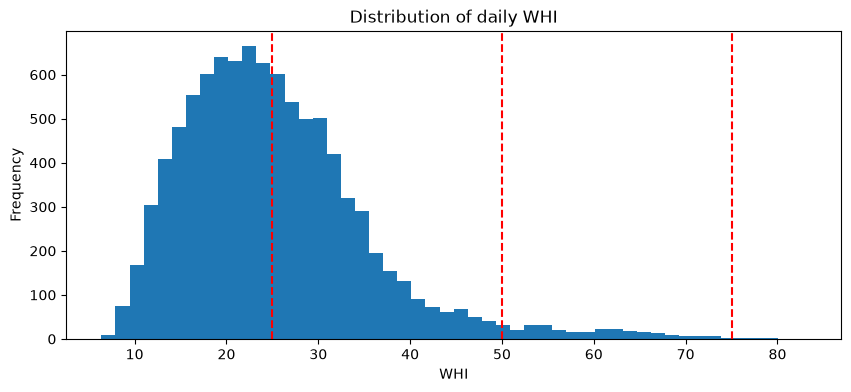

In [26]:
df_daily['whi'].plot(kind='hist', bins=50, figsize=(10, 4), title='Distribution of daily WHI')
for threshold in [25, 50, 75]:
    plt.axvline(threshold, color='red', linestyle='--')
plt.xlabel('WHI')
plt.show()

In [27]:
pd.crosstab(df_daily['date'].dt.month, df_daily['whc'], normalize='index').round(3)

whc,0,1,2,3
date,,,,
1,0.455,0.507,0.037,0.000
2,0.461,0.498,0.039,0.001
3,0.535,0.419,0.045,0.001
4,0.658,0.317,0.024,0.001
5,0.689,0.285,0.026,0.000
6,0.586,0.385,0.026,0.004
7,0.648,0.329,0.020,0.004
8,0.630,0.345,0.024,0.001
9,0.624,0.359,0.017,0.000


In [28]:
same_class = (df_daily['whc'] == df_daily['whc'].shift(-7)).mean()
print(f"Share of days where WHC(t+7) == WHC(t): {same_class:.3f}")

Share of days where WHC(t+7) == WHC(t): 0.501


In [31]:
period = pd.cut(
    df_daily['date'].dt.year,
    bins=[1999, 2019, 2022, 2025],
    labels=['train 2000-2019', 'val 2020-2022', 'test 2023-2025']
)
pd.crosstab(period, df_daily['whc'].map(WHC_LABELS))

whc,Extreme Risk,High Risk,Low Risk,Moderate Risk
date,,,,
train 2000-2019,5,161,4242,2897
val 2020-2022,5,66,481,544
test 2023-2025,1,47,519,529


In [29]:
df_daily.drop(columns=['date', 'whc']).corr()[['cci', 'whi']].sort_values('cci', ascending=False)

,cci,whi
cci,1.000000,-0.716197
shortwave_radiation,0.712508,-0.368026
temperature_2m_max,0.515465,-0.062086
temperature_2m,0.404584,0.102576
apparent_temperature,0.332850,0.081814
temperature_2m_min,0.225468,0.266270
wind_gusts_10m,0.052707,0.476463
wind_speed_10m_max,0.020708,0.452436
dew_point_2m,0.011302,0.259851
wind_speed_10m,-0.108195,0.470741


In [30]:
df_daily.to_csv('../../data/interim/sydney_daily_2000_2025.csv', index=False)